# Visa DataSprint: first look at the data

Goal: understand what is in `datasprint_sample_data.parquet` (~305M transactions, 17.5 GB).

Reading the full file takes ~3-4 minutes, so the notebook works in two layers, both cached in `cache/`:

| Cache file | Built from | Used for |
|---|---|---|
| `agg_full.parquet` | **all** rows, pre-aggregated | volumes over time, categories, geography, issuer countries |
| `sample_cards_1pct.parquet` | **1% of cards** (all their transactions) | amount distributions, per-card behaviour, data quality |

Sampling by card (not by row) keeps the full history of each sampled card, so per-card stats stay valid.
The first run builds the cache (~8 min); every later run takes seconds.

## Column dictionary

My reading of the column names; items marked *(assumption)* should be confirmed with the Visa data contact.

| Column | Meaning |
|---|---|
| `tran_id_raw` | transaction id |
| `tran_id_gmt_tm` | transaction time `HHMMSS`, GMT |
| `pymt_crd_acct_num_raw` | hashed card number (card id) |
| `prod_id_pltfrm_cd_vcis` | product platform: CN = consumer, BZ = business, CO = commercial, GV = government *(assumption)* |
| `transaction_type` | POS / ATM / NA |
| `transaction_pos_entry_mode` | Tap to pay, COF (card on file), Manual key entry, Chip, Magstripe |
| `mrch_regn_*`, `mrch_ctry_*` | merchant region / country |
| `mrch_nm_raw` | merchant name as sent by the terminal (messy) |
| `mrch_catg_cd/nm` | MCC, merchant category |
| `mrch_city_nm_raw`, `mrch_postal_code` | merchant city / postcode as sent (messy, mixed case) |
| `cs_tran_amt` | transaction amount, PLN *(assumption)* |
| `issr_jurn` | card issuer vs merchant: Domestic (Polish card in PL), Intra (other European card), Inter (outside Europe) *(assumption)* |
| `issr_ctry_*` | card issuer country, i.e. where the cardholder comes from |
| `crd_typ_*` | card tier: CLASSIC, INFINITE, BUSINESS, PLATINUM ... |
| `channel_flg` | cp_contactless, mobile (wallet), eci (e-commerce), cash, recur, moto ... |
| `cp_flag` | 1 = card present |
| `prch_mnth_id`, `prch_dt`, `myweek` | purchase month / date / ISO week |
| `report_ctry` | 616 = Poland (constant) |
| `lau_enr` | enriched municipality (LAU) of the merchant |
| `fua_enr` | enriched Functional Urban Area (city + commuter belt), e.g. KRAKOW |
| `pstl_cd_enr` | enriched postcode |

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

import readiness as rd
from paths import CACHE, DATA
CACHE.mkdir(exist_ok=True)
AGG = CACHE / "agg_full.parquet"
SAMPLE = CACHE / "sample_cards_1pct.parquet"
# Categories that pass the 3/75 rule (>= 3 merchants, none above 75%); see check_3_75.py
OK_CATS = rd.passing_3_75("mcc_all")

con = duckdb.connect()
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 50)
plt.rcParams.update({
    "figure.figsize": (12, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

def millions(ax, axis="y"):
    fmt = mtick.FuncFormatter(lambda x, _: f"{x / 1e6:,.1f}M")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)

## Build the cache (slow only on the first run)

One pass over the full file with `GROUPING SETS` produces three aggregates at once:
- **time**: date x GMT hour x issuer jurisdiction x channel
- **geo**: month x FUA x issuer jurisdiction x merchant category
- **country**: month x FUA x issuer country

In [2]:
if not AGG.exists():
    con.sql(f'''
        COPY (
            SELECT
                CASE
                    WHEN GROUPING(prch_dt) = 0 THEN 'time'
                    WHEN GROUPING(mrch_catg_nm) = 0 THEN 'geo'
                    ELSE 'country'
                END AS agg_set,
                prch_dt, hour_gmt, channel_flg,
                prch_mnth_id, fua_enr, mrch_catg_nm,
                issr_jurn, issr_ctry_nm,
                count(*) AS n_tx,
                sum(amount) AS amount
            FROM (
                SELECT
                    prch_dt, channel_flg, prch_mnth_id, fua_enr, mrch_catg_nm,
                    issr_jurn, issr_ctry_nm,
                    CAST(substr(tran_id_gmt_tm, 1, 2) AS INTEGER) AS hour_gmt,
                    CAST(cs_tran_amt AS DOUBLE) AS amount
                FROM '{DATA}'
            )
            GROUP BY GROUPING SETS (
                (prch_dt, hour_gmt, issr_jurn, channel_flg),
                (prch_mnth_id, fua_enr, issr_jurn, mrch_catg_nm),
                (prch_mnth_id, fua_enr, issr_ctry_nm)
            )
        ) TO '{AGG}' (FORMAT parquet)
    ''')

if not SAMPLE.exists():
    con.sql(f'''
        COPY (
            SELECT * FROM '{DATA}'
            WHERE hash(pymt_crd_acct_num_raw) % 100 = 0
        ) TO '{SAMPLE}' (FORMAT parquet)
    ''')

agg = pd.read_parquet(AGG)
t = agg[agg.agg_set == "time"].drop(columns=["prch_mnth_id", "fua_enr", "mrch_catg_nm", "issr_ctry_nm"])
geo = agg[agg.agg_set == "geo"].drop(columns=["prch_dt", "hour_gmt", "channel_flg", "issr_ctry_nm"])
ctry = agg[agg.agg_set == "country"][["prch_mnth_id", "fua_enr", "issr_ctry_nm", "n_tx", "amount"]]

t["date"] = pd.to_datetime(t["prch_dt"])
for df in (geo, ctry):
    df["month"] = pd.to_datetime(df["prch_mnth_id"].astype(int).astype(str), format="%Y%m")

s = con.sql(f"SELECT * FROM '{SAMPLE}'").df()
s["amount"] = s["cs_tran_amt"].astype(float)
print(f"full data: {t.n_tx.sum():,} transactions, {t.amount.sum() / 1e9:,.2f} bn total amount")
print(f"card sample: {len(s):,} transactions, {s.pymt_crd_acct_num_raw.nunique():,} cards")

full data: 305,525,104 transactions, 55.70 bn total amount


card sample: 3,066,582 transactions, 19,423 cards


## 1. Overview

In [3]:
overview = pd.Series({
    "transactions": t.n_tx.sum(),
    "total amount": t.amount.sum(),
    "mean ticket": t.amount.sum() / t.n_tx.sum(),
    "first date": t.date.min().date(),
    "last date": t.date.max().date(),
    "days": t.date.nunique(),
    "est. distinct cards (sample x 100)": s.pymt_crd_acct_num_raw.nunique() * 100,
})
overview.to_frame("value")

,value
transactions,305525104
total amount,"55,697,662,670.58"
mean ticket,182.30
first date,2025-01-01
last date,2026-06-30
days,546
est. distinct cards (sample x 100),1942300


In [4]:
# Column types only: single transactions must not be shown (challenge compliance rules)
s.dtypes.to_frame("dtype")

,dtype
tran_id_raw,int64
tran_id_gmt_tm,object
pymt_crd_acct_num_raw,object
prod_id_pltfrm_cd_vcis,object
transaction_type,object
transaction_pos_entry_mode,object
mrch_regn_cd,object
mrch_regn_nm,object
mrch_ctry_cd,float64
mrch_ctry_nm,object


## 2. Time: how volume changes day by day

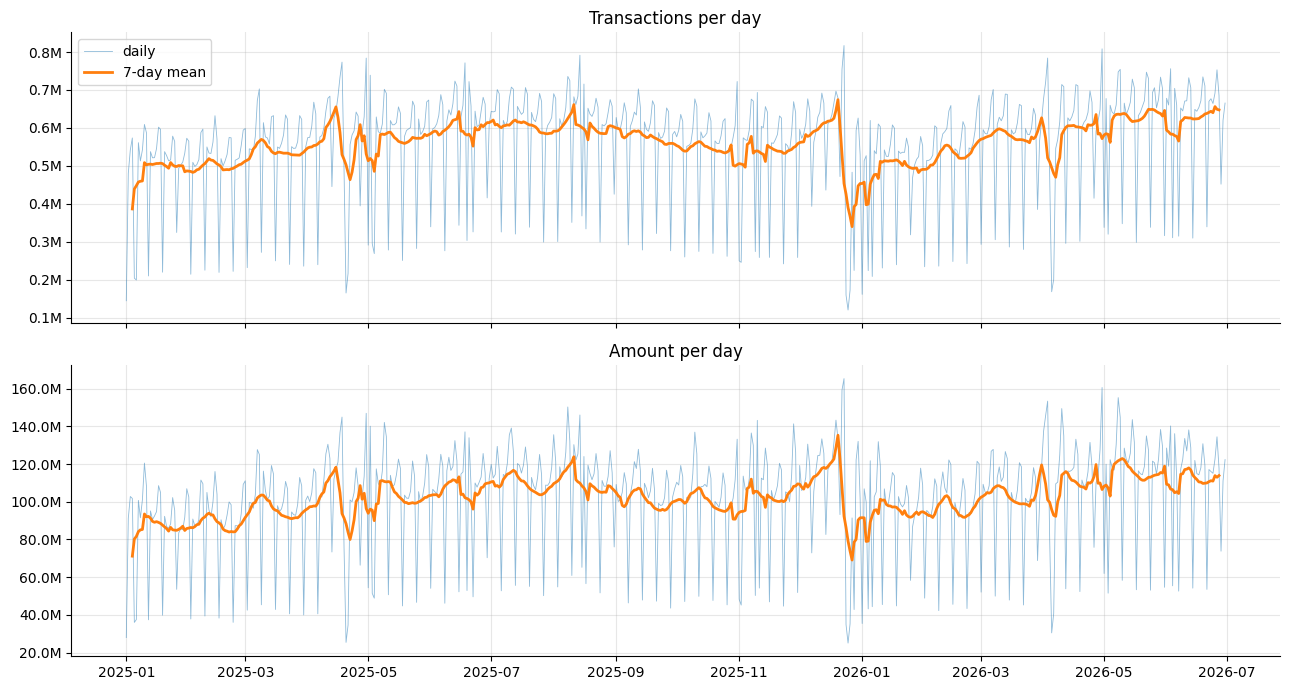

In [5]:
daily = t.groupby("date")[["n_tx", "amount"]].sum()
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, col, title in zip(axes, ["n_tx", "amount"], ["Transactions per day", "Amount per day"]):
    ax.plot(daily.index, daily[col], lw=0.6, alpha=0.5, label="daily")
    ax.plot(daily.index, daily[col].rolling(7, center=True).mean(), lw=2, label="7-day mean")
    ax.set_title(title)
    millions(ax)
axes[0].legend()
plt.tight_layout()

Hours in the data are GMT. Below they are converted to Warsaw local time (CET/CEST).
Caveat: `prch_dt` may itself be a local date, so transactions near midnight can land on the wrong day.

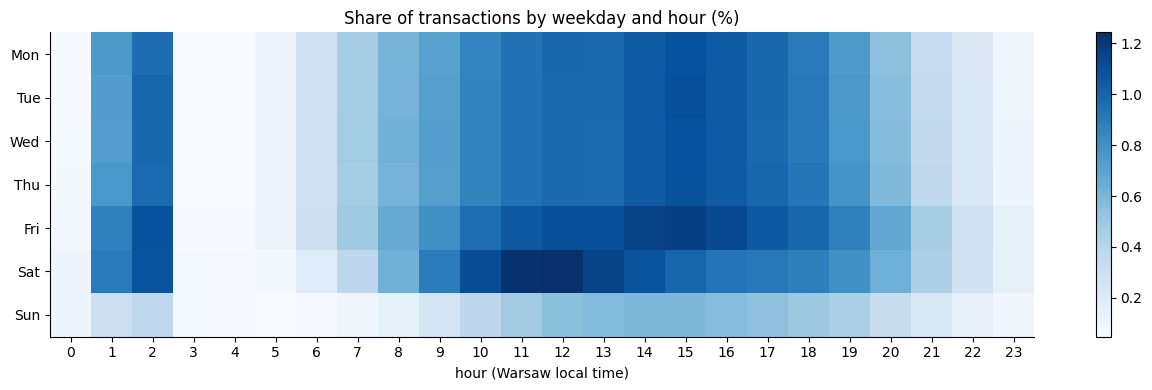

In [6]:
ts_utc = (t["date"] + pd.to_timedelta(t["hour_gmt"], unit="h")).dt.tz_localize("UTC")
ts_local = ts_utc.dt.tz_convert("Europe/Warsaw")
t["hour_local"] = ts_local.dt.hour
t["weekday"] = t["date"].dt.dayofweek  # 0 = Monday

heat = t.pivot_table(index="weekday", columns="hour_local", values="n_tx", aggfunc="sum")
heat = heat / heat.values.sum() * 100

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(heat, aspect="auto", cmap="Blues")
ax.set_yticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax.set_xticks(range(24))
ax.set_xlabel("hour (Warsaw local time)")
ax.set_title("Share of transactions by weekday and hour (%)")
ax.grid(False)
fig.colorbar(im, ax=ax)
plt.tight_layout()

## 3. Who pays: domestic vs foreign cards over time

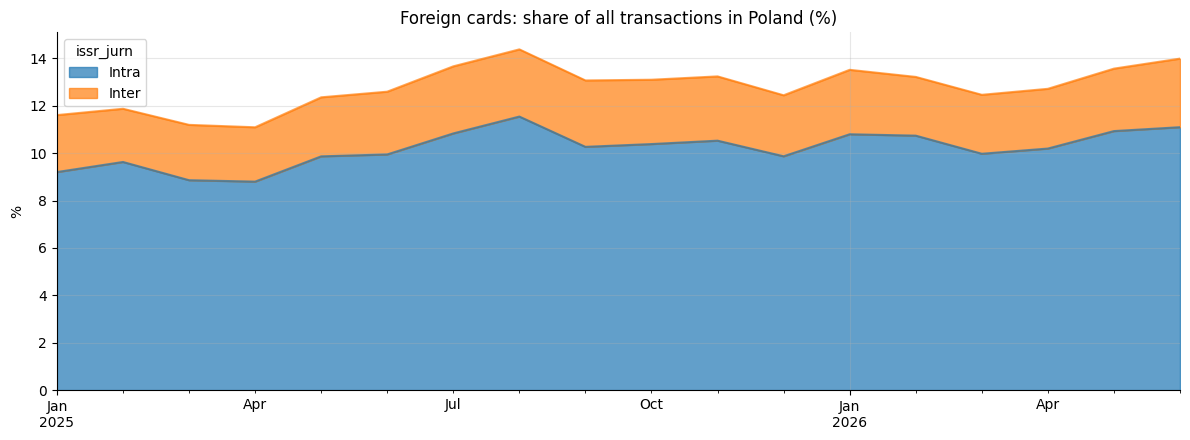

In [7]:
jurn_month = (
    t.assign(month=t.date.dt.to_period("M").dt.to_timestamp())
    .pivot_table(index="month", columns="issr_jurn", values="n_tx", aggfunc="sum")
)
foreign_share = (jurn_month[["Intra", "Inter"]].div(jurn_month.sum(axis=1), axis=0) * 100)

fig, ax = plt.subplots()
foreign_share.plot.area(ax=ax, alpha=0.7)
ax.set_title("Foreign cards: share of all transactions in Poland (%)")
ax.set_ylabel("%")
ax.set_xlabel("")
plt.tight_layout()

## 4. How people pay: channels over time

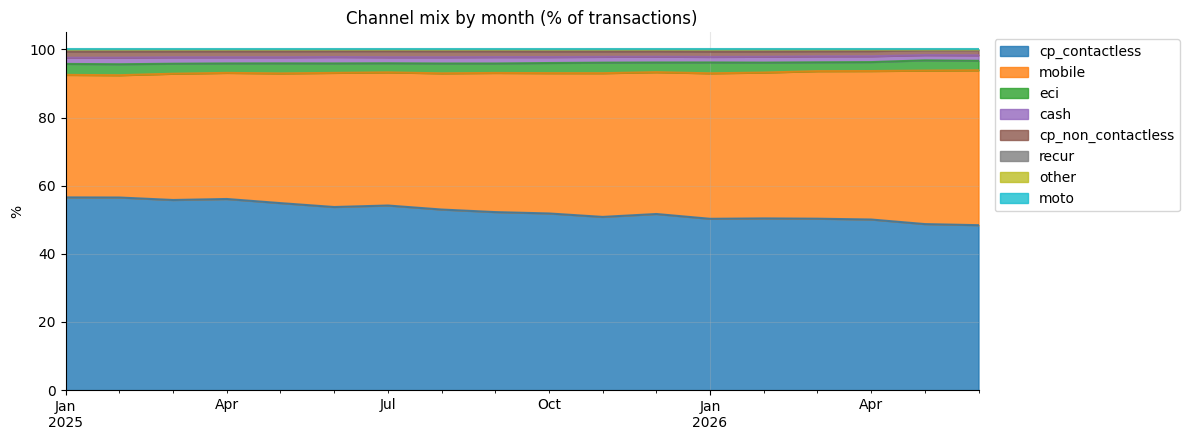

In [8]:
chan = (
    t.assign(month=t.date.dt.to_period("M").dt.to_timestamp())
    .pivot_table(index="month", columns="channel_flg", values="n_tx", aggfunc="sum")
)
chan_share = chan.div(chan.sum(axis=1), axis=0) * 100
chan_share = chan_share[chan_share.mean().sort_values(ascending=False).index]

fig, ax = plt.subplots()
chan_share.plot.area(ax=ax, alpha=0.8, cmap="tab10")
ax.set_title("Channel mix by month (% of transactions)")
ax.set_ylabel("%")
ax.set_xlabel("")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()

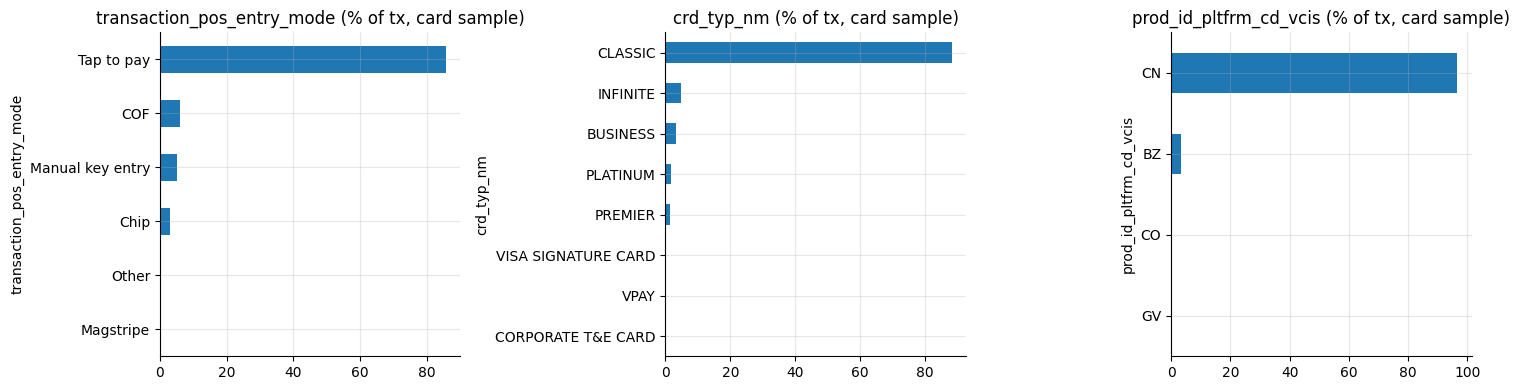

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["transaction_pos_entry_mode", "crd_typ_nm", "prod_id_pltfrm_cd_vcis"]):
    (s[col].value_counts(normalize=True).head(8).sort_values() * 100).plot.barh(ax=ax)
    ax.set_title(f"{col} (% of tx, card sample)")
plt.tight_layout()

## 5. How much: transaction amounts (card sample)

count   3,066,582.00
mean          179.75
std           734.00
min             0.00
1%              1.34
10%             7.45
25%            19.31
50%            54.65
75%           144.73
90%           353.77
99%         2,024.00
max       150,324.50
Name: amount, dtype: float64
zero amounts: 1


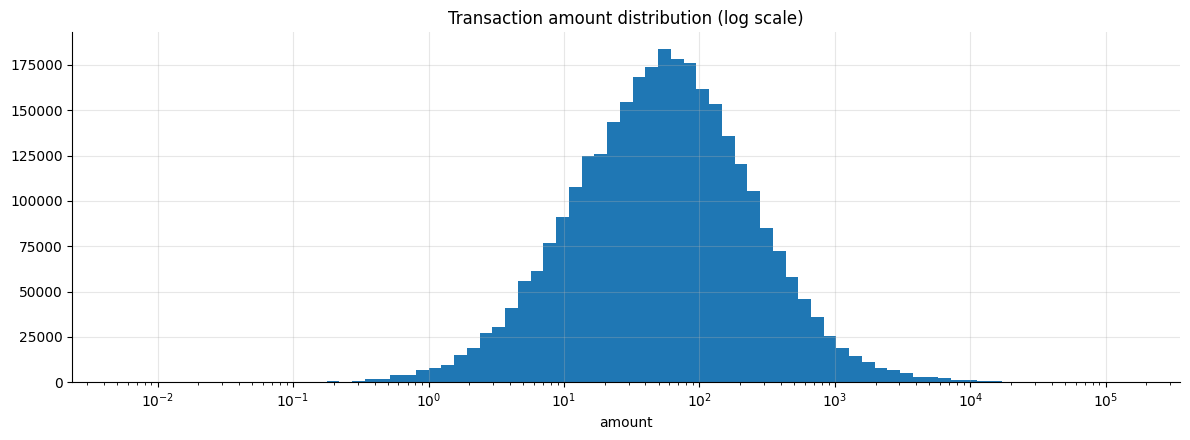

In [10]:
print(s["amount"].describe(percentiles=[0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]))
print(f"zero amounts: {(s.amount == 0).sum():,}")

pos = s.loc[s.amount > 0, "amount"]
fig, ax = plt.subplots()
ax.hist(pos, bins=np.logspace(np.log10(pos.min()), np.log10(pos.max()), 80))
ax.set_xscale("log")
ax.set_title("Transaction amount distribution (log scale)")
ax.set_xlabel("amount")
plt.tight_layout()

## 6. What people buy: merchant categories (full data)

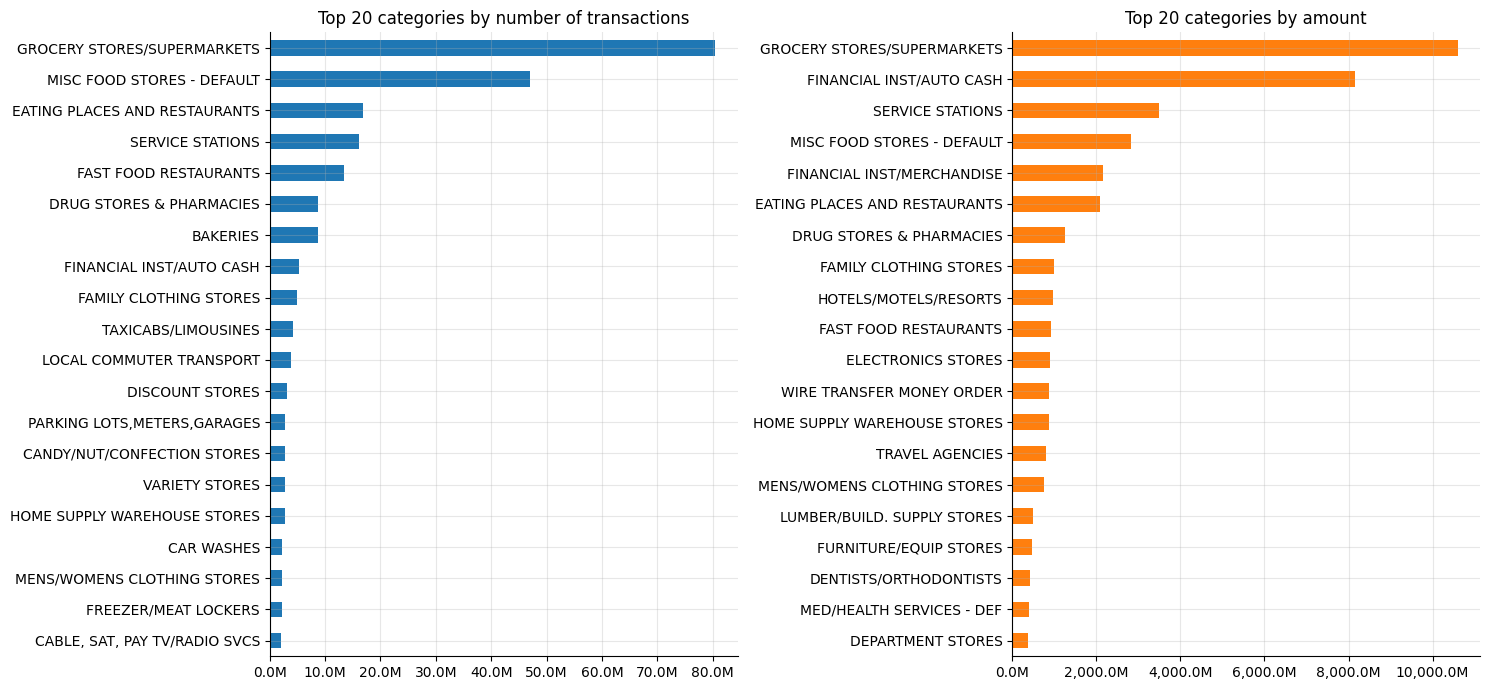

In [11]:
cat = geo.groupby("mrch_catg_nm")[["n_tx", "amount"]].sum()
cat = cat[cat.index.isin(OK_CATS)]  # show only categories that pass the 3/75 rule
cat["avg_ticket"] = cat.amount / cat.n_tx

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
cat.n_tx.nlargest(20).sort_values().plot.barh(ax=axes[0], title="Top 20 categories by number of transactions")
cat.amount.nlargest(20).sort_values().plot.barh(ax=axes[1], title="Top 20 categories by amount", color="C1")
millions(axes[0], "x")
millions(axes[1], "x")
for ax in axes:
    ax.set_ylabel("")
plt.tight_layout()

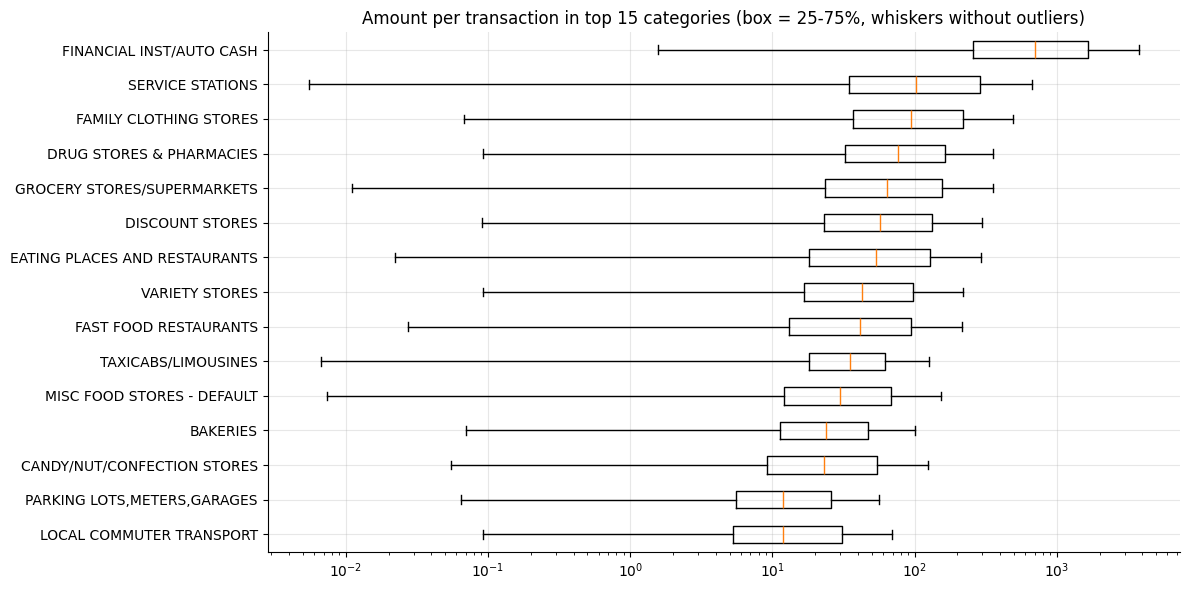

In [12]:
# Median ticket in the biggest categories (card sample)
top_cats = cat.n_tx.nlargest(15).index
box = s[s.mrch_catg_nm.isin(top_cats) & (s.amount > 0)]
order = box.groupby("mrch_catg_nm").amount.median().sort_values().index

fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot([box.loc[box.mrch_catg_nm == c, "amount"] for c in order], vert=False, showfliers=False)
ax.set_yticks(range(1, len(order) + 1), order)
ax.set_xscale("log")
ax.set_title("Amount per transaction in top 15 categories (box = 25-75%, whiskers without outliers)")
plt.tight_layout()

## 7. Where: Functional Urban Areas (full data)

`fua_enr` is empty for ~23% of transactions (foreign merchants, online, rural areas outside any FUA).

share of tx without FUA: 23.9%


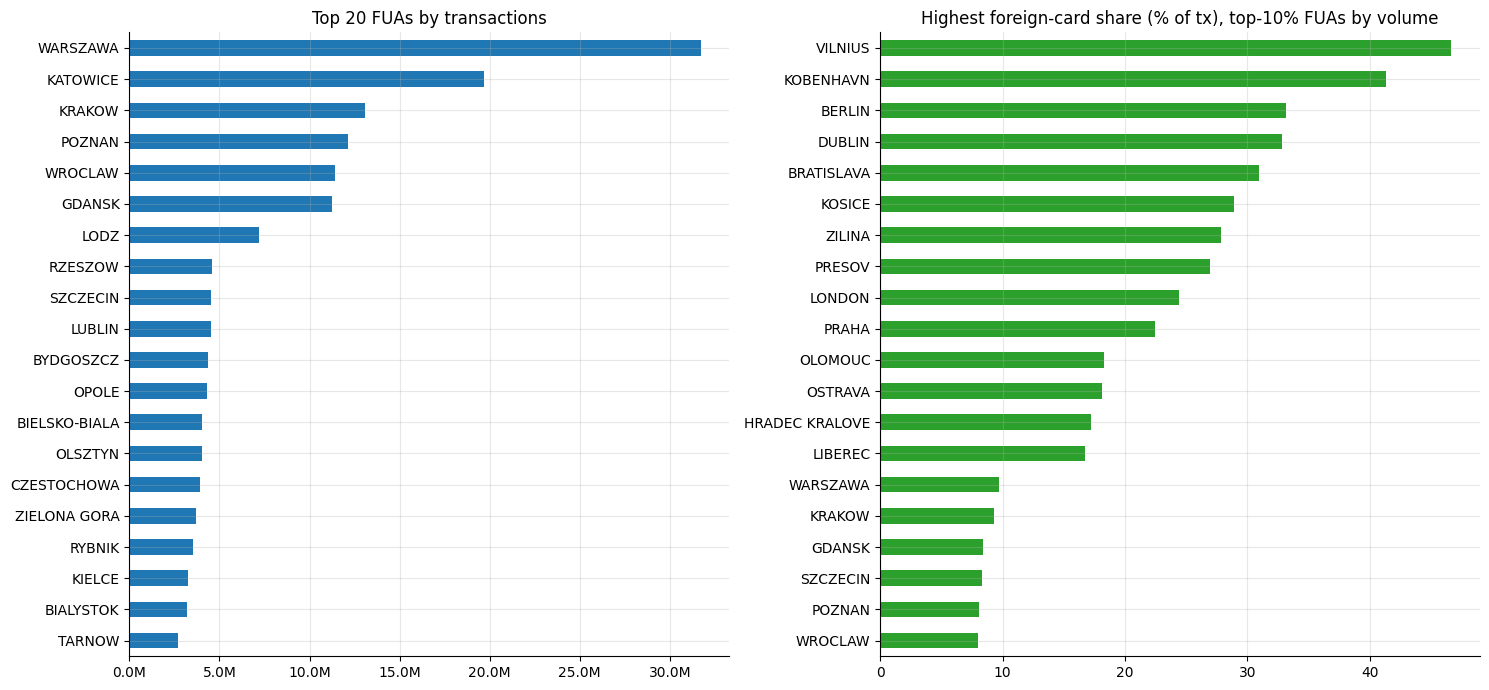

In [13]:
fua = geo.groupby("fua_enr", dropna=False)[["n_tx", "amount"]].sum()
print(f"share of tx without FUA: {fua.loc[fua.index.isna(), 'n_tx'].sum() / fua.n_tx.sum():.1%}")
fua = fua[fua.index.notna()]

jurn = geo.dropna(subset=["fua_enr"]).pivot_table(index="fua_enr", columns="issr_jurn", values="n_tx", aggfunc="sum").fillna(0)
fua["foreign_share"] = (jurn["Intra"] + jurn["Inter"]) / jurn.sum(axis=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fua.n_tx.nlargest(20).sort_values().plot.barh(ax=axes[0], title="Top 20 FUAs by transactions")
millions(axes[0], "x")
big = fua[fua.n_tx > fua.n_tx.quantile(0.9)]
big.foreign_share.nlargest(20).sort_values().plot.barh(ax=axes[1], color="C2",
    title="Highest foreign-card share (% of tx), top-10% FUAs by volume")
for ax in axes:
    ax.set_ylabel("")
plt.tight_layout()

## 8. Tourism: seasonality of foreign spending by city

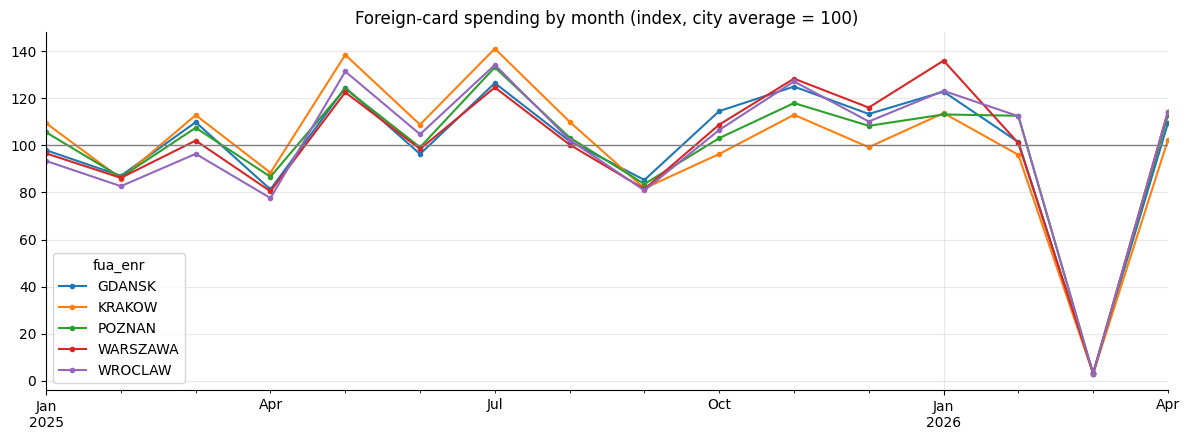

In [14]:
cities = ["KRAKOW", "WARSZAWA", "GDANSK", "WROCLAW", "ZAKOPANE", "POZNAN"]
cities = [c for c in cities if c in fua.index]
foreign = geo[geo.fua_enr.isin(cities) & geo.issr_jurn.isin(["Intra", "Inter"])]
fm = foreign.pivot_table(index="month", columns="fua_enr", values="amount", aggfunc="sum")
fm_index = fm / fm.mean() * 100

fig, ax = plt.subplots()
fm_index.plot(ax=ax, marker="o", ms=3)
ax.axhline(100, color="grey", lw=1)
ax.set_title("Foreign-card spending by month (index, city average = 100)")
ax.set_xlabel("")
plt.tight_layout()

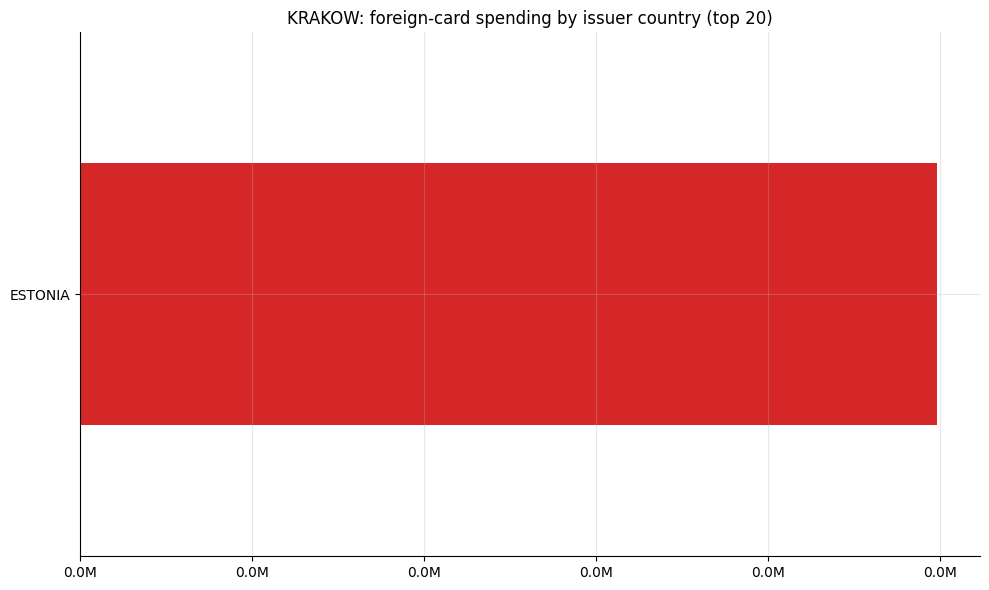

In [15]:
CITY = "KRAKOW"
kr = ctry[(ctry.fua_enr == CITY) & (ctry.issr_ctry_nm != "POLAND")]
top_ctry = kr.groupby("issr_ctry_nm")[["n_tx", "amount"]].sum().nlargest(20, "amount")

fig, ax = plt.subplots(figsize=(10, 6))
top_ctry.amount.sort_values().plot.barh(ax=ax, color="C3")
millions(ax, "x")
ax.set_title(f"{CITY}: foreign-card spending by issuer country (top 20)")
ax.set_ylabel("")
plt.tight_layout()

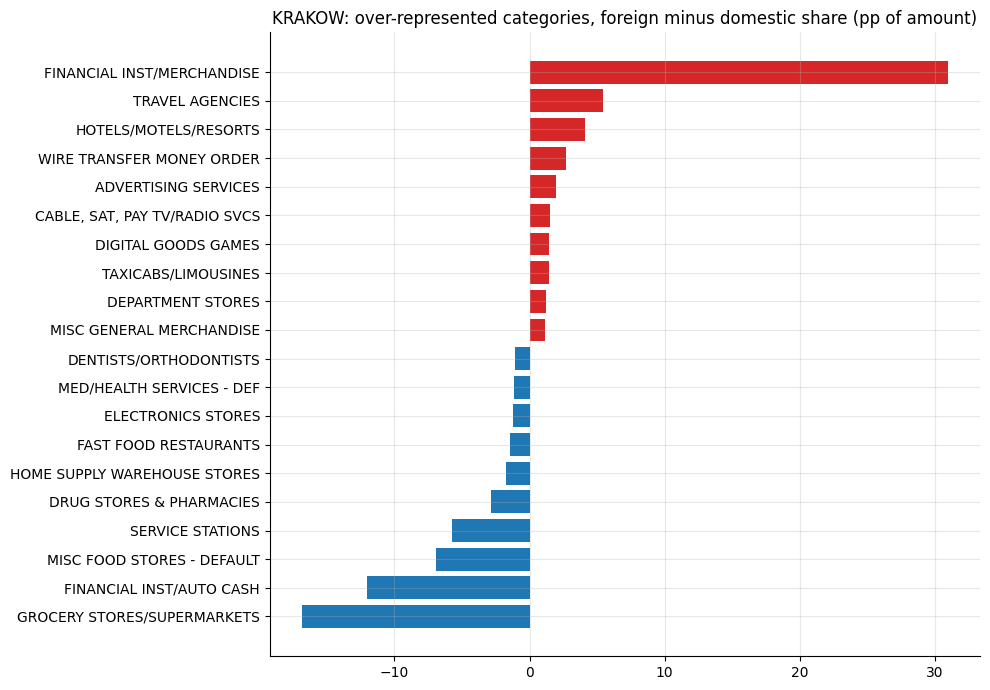

In [16]:
# What foreigners buy in the city vs locals: share of amount per category
kg = geo[geo.fua_enr == CITY].assign(
    who=lambda d: np.where(d.issr_jurn == "Domestic", "domestic", "foreign"))
mix = kg.pivot_table(index="mrch_catg_nm", columns="who", values="amount", aggfunc="sum").fillna(0)
mix = mix / mix.sum() * 100
mix["diff"] = mix.foreign - mix.domestic
mix = mix[mix.index.isin(OK_CATS)]  # show only categories that pass the 3/75 rule
show = pd.concat([mix.nlargest(10, "diff"), mix.nsmallest(10, "diff")]).sort_values("diff")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(show.index, show["diff"], color=np.where(show["diff"] > 0, "C3", "C0"))
ax.set_title(f"{CITY}: over-represented categories, foreign minus domestic share (pp of amount)")
plt.tight_layout()

## 9. Cards: how people behave (card sample)

           n_tx       amount  active_months  categories      fuas
count 19,423.00    19,423.00      19,423.00   19,423.00 19,423.00
mean     157.88    28,378.88           8.56       17.87      0.85
std      230.54    48,994.38           7.05       15.20      0.80
min        1.00         0.25           1.00        1.00      0.00
25%       12.00     2,057.21           2.00        5.00      0.00
50%       53.00    10,070.12           6.00       14.00      1.00
75%      212.00    37,213.05          17.00       27.00      1.00
90%      474.00    78,330.82          18.00       40.00      2.00
99%    1,013.00   203,350.25          18.00       63.00      3.00
max    3,860.00 1,505,249.01          18.00      101.00      8.00


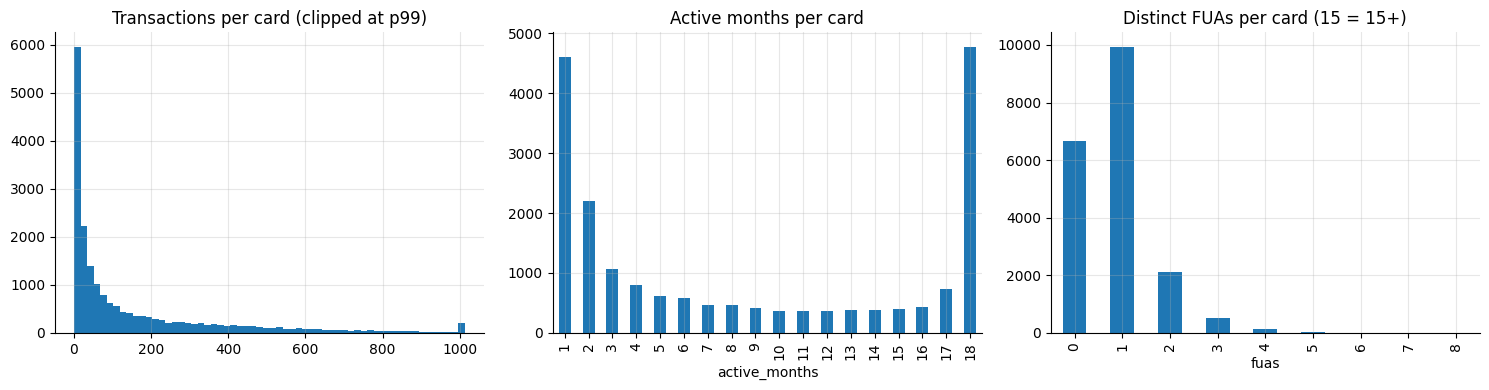

In [17]:
per_card = s.groupby("pymt_crd_acct_num_raw").agg(
    n_tx=("tran_id_raw", "size"),
    amount=("amount", "sum"),
    active_months=("prch_mnth_id", "nunique"),
    categories=("mrch_catg_nm", "nunique"),
    fuas=("fua_enr", "nunique"),
)
print(per_card.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(per_card.n_tx.clip(upper=per_card.n_tx.quantile(0.99)), bins=60)
axes[0].set_title("Transactions per card (clipped at p99)")
per_card.active_months.value_counts().sort_index().plot.bar(ax=axes[1], title="Active months per card")
per_card.fuas.clip(upper=15).value_counts().sort_index().plot.bar(ax=axes[2], title="Distinct FUAs per card (15 = 15+)")
plt.tight_layout()

## 10. Data quality (card sample)

In [18]:
nulls = (s.isna().mean() * 100).sort_values(ascending=False)
nulls[nulls > 0].to_frame("% null")

,% null
lau_enr,23.80
fua_enr,23.80
pstl_cd_enr,23.79
mrch_postal_code,5.03


In [19]:
# Raw city names are messy (casing, spelling); prefer lau_enr / fua_enr for geography
print("raw city spellings mapped to LAU KRAKOW:")
print(s.loc[s.lau_enr == "KRAKOW", "mrch_city_nm_raw"].value_counts().head(15))

raw city spellings mapped to LAU KRAKOW:


mrch_city_nm_raw
KRAKOW           35719
Krakow           14514
Warszawa          1095
WARSZAWA          1069
Poznan             938
Warsaw             917
AMSTERDAM          703
Dublin             590
Liszki             557
APPLE.COM/BIL      498
KRAKOW (KRAKO      485
Lodz               401
Vilnius            382
HELP.UBER.COM      312
Wroclaw            249
Name: count, dtype: int64


In [20]:
print(s.transaction_type.value_counts())
print()
print(s.groupby("transaction_type").amount.describe())

transaction_type
POS    2994906
ATM      53351
NA       18325
Name: count, dtype: int64



                        count     mean      std  min    25%    50%      75%  \
transaction_type                                                              
ATM                 53,351.00 1,414.73 2,305.42 1.56 257.60 699.20 1,656.00   
NA                  18,325.00   430.78 1,201.48 0.01  42.14 119.60   340.44   
POS              2,994,906.00   156.21   648.10 0.00  18.82  52.58   137.75   

                        max  
transaction_type             
ATM               69,571.85  
NA                25,886.66  
POS              150,324.50  
